# 🎬 IMDB Dataset — SQL Query Analysis
A complete end-to-end project: dataset creation, SQL analysis, and visualizations using SQLite + pandas + matplotlib.

## 1. Setup & Imports

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Aesthetics
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Create SQLite Database & Populate with Synthetic IMDB-style Data

In [2]:
conn = sqlite3.connect(':memory:')
cur = conn.cursor()

# --- Schema ---
cur.executescript('''
CREATE TABLE movies (
    movie_id     INTEGER PRIMARY KEY,
    title        TEXT NOT NULL,
    release_year INTEGER,
    genre        TEXT,
    imdb_rating  REAL,
    votes        INTEGER,
    budget_usd   INTEGER,
    gross_usd    INTEGER,
    runtime_min  INTEGER,
    country      TEXT,
    language     TEXT,
    director_id  INTEGER
);

CREATE TABLE directors (
    director_id INTEGER PRIMARY KEY,
    name        TEXT NOT NULL,
    birth_year  INTEGER,
    nationality TEXT
);

CREATE TABLE actors (
    actor_id   INTEGER PRIMARY KEY,
    name       TEXT NOT NULL,
    birth_year INTEGER,
    gender     TEXT
);

CREATE TABLE movie_actors (
    movie_id INTEGER,
    actor_id INTEGER,
    role     TEXT,
    PRIMARY KEY (movie_id, actor_id)
);
''')

print('✅ Schema created')

✅ Schema created


In [3]:
import random
random.seed(42)
np.random.seed(42)

# Directors
directors = [
    (1,'Christopher Nolan',1970,'British'),
    (2,'Steven Spielberg',1946,'American'),
    (3,'Martin Scorsese',1942,'American'),
    (4,'Quentin Tarantino',1963,'American'),
    (5,'Denis Villeneuve',1967,'Canadian'),
    (6,'Ridley Scott',1937,'British'),
    (7,'David Fincher',1962,'American'),
    (8,'James Cameron',1954,'Canadian'),
    (9,'Francis Ford Coppola',1939,'American'),
    (10,'Stanley Kubrick',1928,'American'),
    (11,'Wes Anderson',1969,'American'),
    (12,'Alfonso Cuarón',1961,'Mexican'),
    (13,'Hayao Miyazaki',1941,'Japanese'),
    (14,'Bong Joon-ho',1969,'South Korean'),
    (15,'Pedro Almodóvar',1949,'Spanish'),
]
cur.executemany('INSERT INTO directors VALUES (?,?,?,?)', directors)

# Movies
genres = ['Drama','Action','Thriller','Comedy','Sci-Fi','Crime','Biography','Horror','Romance','Animation']
countries = ['USA','UK','Canada','France','Japan','South Korea','Italy','Spain','Germany','Australia']
languages = ['English','French','Japanese','Korean','Spanish','Italian','German']

titles_pool = [
    'Inception','Interstellar','The Dark Knight','Dunkirk','Tenet',
    'Schindlers List','Jaws','E.T.','Jurassic Park','Saving Private Ryan',
    'Goodfellas','Taxi Driver','The Departed','Shutter Island','Casino',
    'Pulp Fiction','Kill Bill','Inglourious Basterds','Django Unchained','The Hateful Eight',
    'Arrival','Blade Runner 2049','Dune','Prisoners','Enemy',
    'Alien','Gladiator','The Martian','Blade Runner','Prometheus',
    'Fight Club','Se7en','Zodiac','Gone Girl','Mank',
    'Avatar','Titanic','Terminator 2','The Abyss','Aliens',
    'The Godfather','The Godfather Part II','Apocalypse Now','Rumble Fish','The Conversation',
    '2001 A Space Odyssey','A Clockwork Orange','The Shining','Full Metal Jacket','Dr. Strangelove',
    'The Grand Budapest Hotel','Moonrise Kingdom','The Royal Tenenbaums','Rushmore','Fantastic Mr Fox',
    'Gravity','Y Tu Mama También','Children of Men','Roma','A Little Princess',
    'Spirited Away','Princess Mononoke','My Neighbor Totoro','Howls Moving Castle','Nausicaa',
    'Parasite','Memories of Murder','Snowpiercer','Okja','Mother',
    'All About My Mother','Talk to Her','Volver','Pain and Glory','The Skin I Live In',
    'Rear Window','Vertigo','Psycho','North by Northwest','Rope',   # extra
    'Heat','L.A. Confidential','Mulholland Drive','Blue Velvet','Twin Peaks Fire Walk With Me',
    'No Country for Old Men','Fargo','True Grit','Burn After Reading','Blood Simple',
    'The Silence of the Lambs','Hannibal','Red Dragon','Manhunter','Black Swan',
    'Whiplash','La La Land','First Man','Damien Chazelle Film','Babylon',
]

movies = []
for i, title in enumerate(titles_pool, 1):
    yr = random.randint(1970, 2023)
    genre = genres[i % len(genres)]
    rating = round(np.clip(np.random.normal(7.2, 0.9), 4.5, 9.5), 1)
    votes = random.randint(5_000, 2_500_000)
    budget = random.randint(1_000_000, 250_000_000)
    gross = int(budget * np.clip(np.random.normal(1.8, 1.2), 0.05, 8.0))
    runtime = random.randint(75, 195)
    country = countries[i % len(countries)]
    language = languages[i % len(languages)]
    director_id = (i % 15) + 1
    movies.append((i, title, yr, genre, rating, votes, budget, gross, runtime, country, language, director_id))

cur.executemany('INSERT INTO movies VALUES (?,?,?,?,?,?,?,?,?,?,?,?)', movies)

# Actors
actors_data = [
    (1,'Leonardo DiCaprio',1974,'M'),(2,'Meryl Streep',1949,'F'),
    (3,'Tom Hanks',1956,'M'),(4,'Cate Blanchett',1969,'F'),
    (5,'Brad Pitt',1963,'M'),(6,'Natalie Portman',1981,'F'),
    (7,'Joaquin Phoenix',1974,'M'),(8,'Viola Davis',1965,'F'),
    (9,'Christian Bale',1974,'M'),(10,'Scarlett Johansson',1984,'F'),
    (11,'Denzel Washington',1954,'M'),(12,'Saoirse Ronan',1994,'F'),
    (13,'Robert De Niro',1943,'M'),(14,'Frances McDormand',1957,'F'),
    (15,'Morgan Freeman',1937,'M'),(16,'Amy Adams',1974,'F'),
    (17,'Al Pacino',1940,'M'),(18,'Emma Stone',1988,'F'),
    (19,'Matt Damon',1970,'M'),(20,'Jennifer Lawrence',1990,'F'),
]
cur.executemany('INSERT INTO actors VALUES (?,?,?,?)', actors_data)

# Movie-Actor links
roles = ['Lead','Supporting','Cameo']
links = set()
for movie_id in range(1, len(movies)+1):
    chosen = random.sample(range(1,21), k=random.randint(2,5))
    for actor_id in chosen:
        if (movie_id, actor_id) not in links:
            links.add((movie_id, actor_id))
            cur.execute('INSERT INTO movie_actors VALUES (?,?,?)',
                        (movie_id, actor_id, random.choice(roles)))

conn.commit()
print(f'✅ Data inserted: {len(movies)} movies, {len(actors_data)} actors, {len(directors)} directors, {len(links)} cast links')

✅ Data inserted: 100 movies, 20 actors, 15 directors, 377 cast links


## 3. Helper — Run SQL & Preview

In [4]:
def sql(query, n=10):
    df = pd.read_sql_query(query, conn)
    display(df.head(n))
    return df

---
## 4. Basic Exploration Queries

### 4.1 Total counts across all tables

In [5]:
sql('''
SELECT
    (SELECT COUNT(*) FROM movies)       AS total_movies,
    (SELECT COUNT(*) FROM directors)    AS total_directors,
    (SELECT COUNT(*) FROM actors)       AS total_actors,
    (SELECT COUNT(*) FROM movie_actors) AS total_cast_links
''')

,total_movies,total_directors,total_actors,total_cast_links
0,100,15,20,377


,total_movies,total_directors,total_actors,total_cast_links
0,100,15,20,377


### 4.2 Top 10 highest-rated movies

In [6]:
top_rated = sql('''
SELECT m.title, m.release_year, m.genre, m.imdb_rating, m.votes,
       d.name AS director
FROM movies m
JOIN directors d ON m.director_id = d.director_id
ORDER BY m.imdb_rating DESC
LIMIT 10
''')

,title,release_year,genre,imdb_rating,votes,director
0,Rushmore,2016,Sci-Fi,8.9,2043391,Stanley Kubrick
1,North by Northwest,1974,Animation,8.9,1863625,Denis Villeneuve
2,Dunkirk,2004,Sci-Fi,8.6,369647,Denis Villeneuve
3,Goodfellas,1991,Action,8.5,1170476,Alfonso Cuarón
4,The Godfather Part II,1977,Thriller,8.5,2257216,Hayao Miyazaki
5,Princess Mononoke,1984,Thriller,8.5,273544,Martin Scorsese
6,A Little Princess,1995,Drama,8.2,1571239,Christopher Nolan
7,L.A. Confidential,2018,Thriller,8.2,996447,James Cameron
8,The Martian,1972,Romance,8.1,1328105,Bong Joon-ho
9,Mulholland Drive,2001,Comedy,8.1,2023963,Francis Ford Coppola


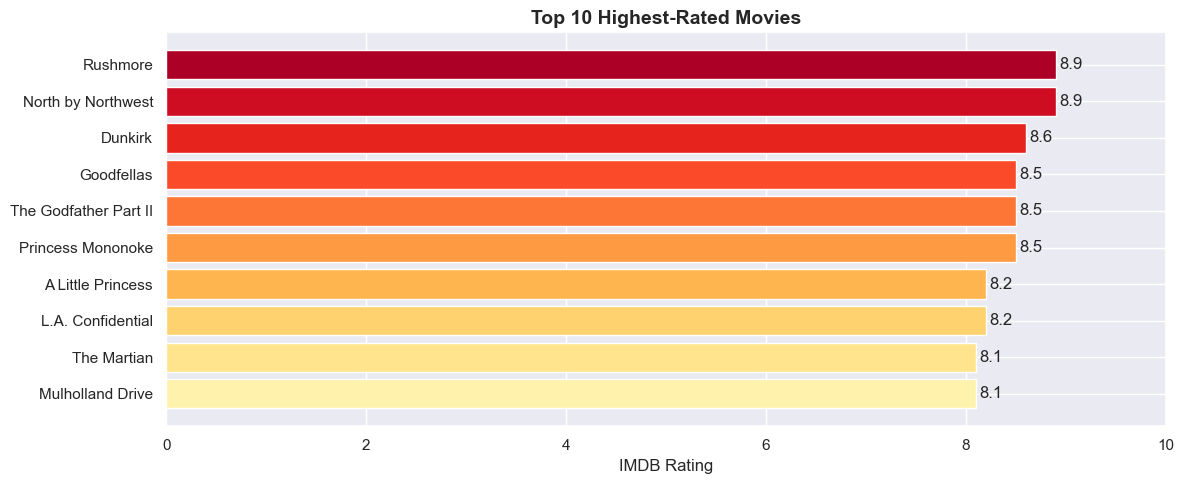

In [7]:
fig, ax = plt.subplots(figsize=(12,5))
bars = ax.barh(top_rated['title'], top_rated['imdb_rating'],
               color=sns.color_palette('YlOrRd_r', len(top_rated)))
ax.set_xlim(0, 10)
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_xlabel('IMDB Rating')
ax.set_title('Top 10 Highest-Rated Movies')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 4.3 Genre distribution

In [8]:
genre_dist = sql('''
SELECT genre,
       COUNT(*)                   AS num_movies,
       ROUND(AVG(imdb_rating),2)  AS avg_rating,
       ROUND(AVG(gross_usd/1e6),1) AS avg_gross_m
FROM movies
GROUP BY genre
ORDER BY num_movies DESC
''')

,genre,num_movies,avg_rating,avg_gross_m
0,Thriller,10,7.25,117.4
1,Sci-Fi,10,7.35,336.7
2,Romance,10,6.89,207.8
3,Horror,10,6.96,348.0
4,Drama,10,7.09,213.6
5,Crime,10,7.10,167.7
6,Comedy,10,7.13,291.6
7,Biography,10,6.77,303.6
8,Animation,10,7.11,266.3
9,Action,10,7.31,130.1


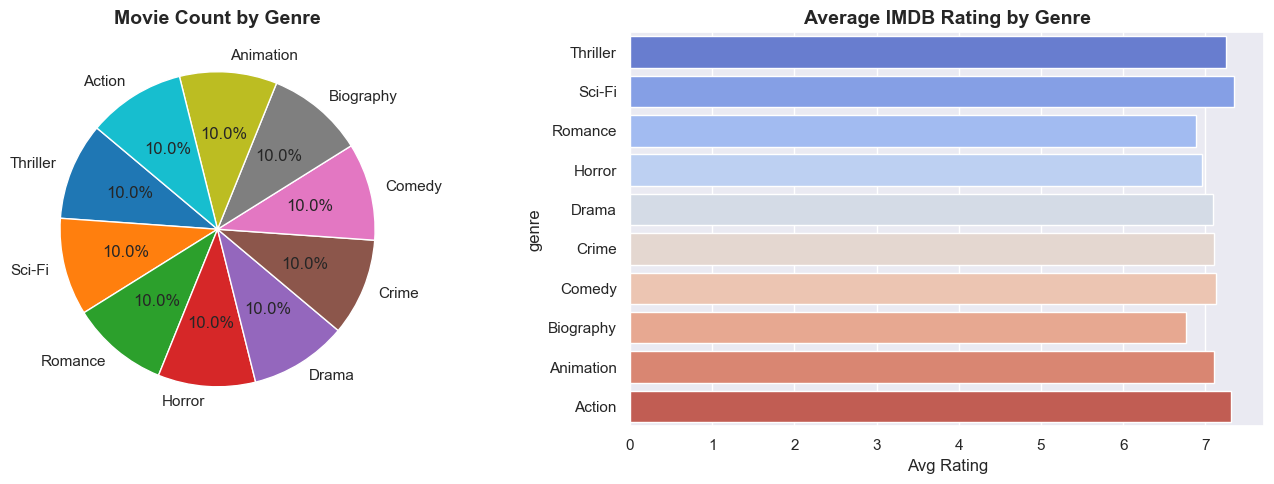

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(genre_dist['num_movies'], labels=genre_dist['genre'],
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('tab10', len(genre_dist)))
axes[0].set_title('Movie Count by Genre')

# Avg rating bar
sns.barplot(data=genre_dist, y='genre', x='avg_rating', ax=axes[1],
            palette='coolwarm')
axes[1].set_title('Average IMDB Rating by Genre')
axes[1].set_xlabel('Avg Rating')

plt.tight_layout()
plt.show()

---
## 5. Intermediate SQL Queries

### 5.1 Movies released per decade

In [10]:
decade_df = sql('''
SELECT (release_year / 10) * 10  AS decade,
       COUNT(*)                  AS num_movies,
       ROUND(AVG(imdb_rating),2) AS avg_rating
FROM movies
GROUP BY decade
ORDER BY decade
''')

,decade,num_movies,avg_rating
0,1970,16,7.09
1,1980,19,7.04
2,1990,18,7.18
3,2000,23,7.07
4,2010,21,7.09
5,2020,3,7.17


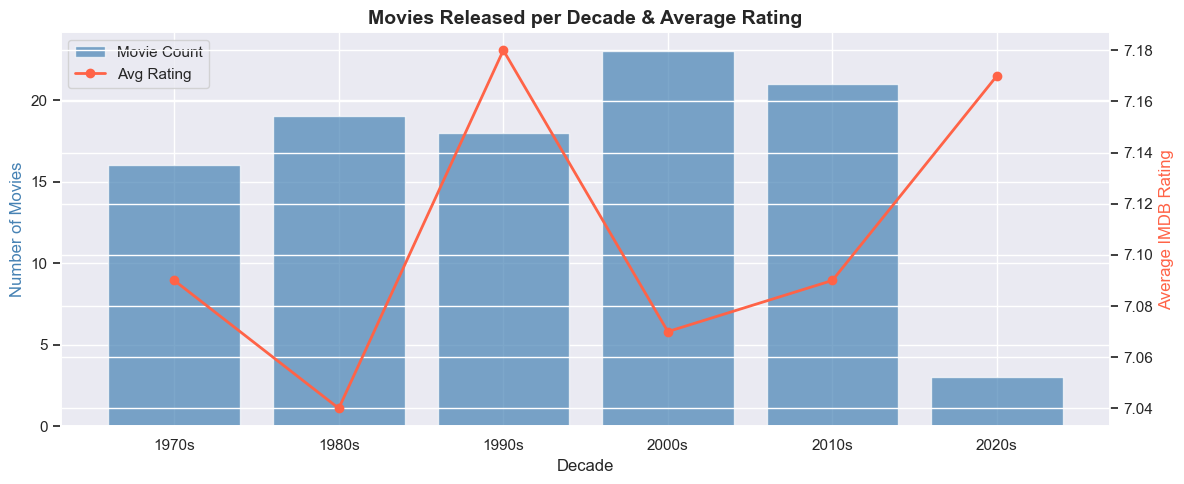

In [11]:
fig, ax1 = plt.subplots(figsize=(12,5))
ax2 = ax1.twinx()
ax1.bar(decade_df['decade'].astype(str)+'s', decade_df['num_movies'],
        color='steelblue', alpha=0.7, label='Movie Count')
ax2.plot(decade_df['decade'].astype(str)+'s', decade_df['avg_rating'],
         color='tomato', marker='o', linewidth=2, label='Avg Rating')
ax1.set_xlabel('Decade')
ax1.set_ylabel('Number of Movies', color='steelblue')
ax2.set_ylabel('Average IMDB Rating', color='tomato')
ax1.set_title('Movies Released per Decade & Average Rating')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.show()

### 5.2 Director performance — avg rating & total gross

In [12]:
director_perf = sql('''
SELECT d.name                         AS director,
       COUNT(m.movie_id)              AS num_movies,
       ROUND(AVG(m.imdb_rating),2)    AS avg_rating,
       ROUND(SUM(m.gross_usd)/1e6, 1) AS total_gross_m,
       ROUND(AVG(m.gross_usd/
             NULLIF(m.budget_usd,0)),2) AS avg_roi
FROM directors d
JOIN movies m ON d.director_id = m.director_id
GROUP BY d.director_id
HAVING num_movies >= 3
ORDER BY avg_rating DESC
''')

,director,num_movies,avg_rating,total_gross_m,avg_roi
0,Denis Villeneuve,7,7.63,2199.4,1.57
1,Quentin Tarantino,7,7.40,1978.7,1.43
2,Steven Spielberg,7,7.36,1979.2,1.43
3,Christopher Nolan,6,7.30,2517.7,2.33
4,Wes Anderson,7,7.26,551.5,0.14
5,James Cameron,7,7.20,1677.8,0.86
6,Bong Joon-ho,6,7.18,1500.3,1.67
7,Stanley Kubrick,7,7.16,2084.6,2.00
8,Hayao Miyazaki,6,7.10,2144.7,1.83
9,Alfonso Cuarón,6,7.05,972.2,1.33


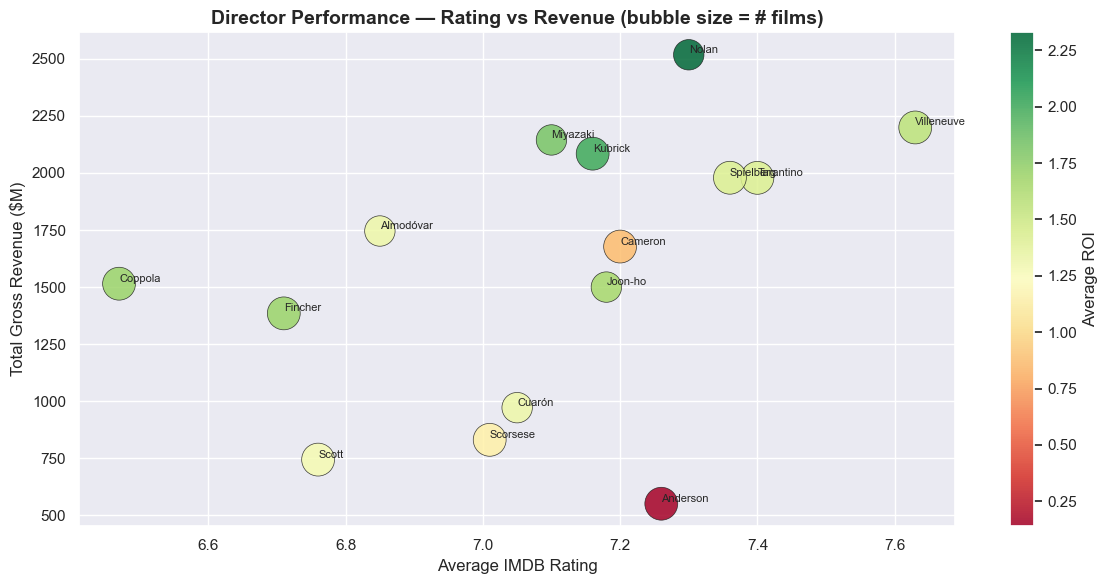

In [13]:
fig, ax = plt.subplots(figsize=(12,6))
scatter = ax.scatter(director_perf['avg_rating'],
                     director_perf['total_gross_m'],
                     s=director_perf['num_movies']*80,
                     c=director_perf['avg_roi'],
                     cmap='RdYlGn', alpha=0.85, edgecolors='k', linewidth=0.5)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Average ROI')
for _, row in director_perf.iterrows():
    ax.annotate(row['director'].split()[-1],
                (row['avg_rating'], row['total_gross_m']),
                fontsize=8, ha='left', va='bottom')
ax.set_xlabel('Average IMDB Rating')
ax.set_ylabel('Total Gross Revenue ($M)')
ax.set_title('Director Performance — Rating vs Revenue (bubble size = # films)')
plt.tight_layout()
plt.show()

### 5.3 Rating distribution — histogram

,imdb_rating
0,7.6
1,7.8
2,7.0
3,8.6
4,6.8
5,6.8
6,7.4
7,5.6
8,6.3
9,6.4


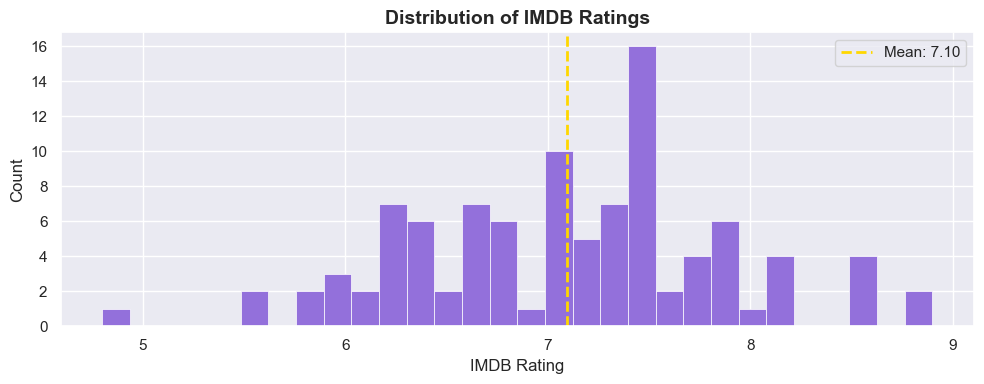

In [14]:
ratings_df = sql('SELECT imdb_rating FROM movies')

fig, ax = plt.subplots(figsize=(10,4))
ax.hist(ratings_df['imdb_rating'], bins=30, color='mediumpurple',
        edgecolor='white', linewidth=0.5)
ax.axvline(ratings_df['imdb_rating'].mean(), color='gold', linewidth=2,
           linestyle='--', label=f"Mean: {ratings_df['imdb_rating'].mean():.2f}")
ax.set_xlabel('IMDB Rating')
ax.set_ylabel('Count')
ax.set_title('Distribution of IMDB Ratings')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Advanced SQL Queries

### 6.1 Most prolific actors (by film count + avg rating of their films)

In [15]:
actor_stats = sql('''
SELECT a.name                         AS actor,
       a.gender,
       COUNT(ma.movie_id)             AS num_films,
       ROUND(AVG(m.imdb_rating),2)    AS avg_film_rating,
       ROUND(SUM(m.gross_usd)/1e6,1)  AS total_film_gross_m
FROM actors a
JOIN movie_actors ma ON a.actor_id = ma.actor_id
JOIN movies m        ON ma.movie_id = m.movie_id
GROUP BY a.actor_id
ORDER BY num_films DESC
LIMIT 15
''')

,actor,gender,num_films,avg_film_rating,total_film_gross_m
0,Jennifer Lawrence,F,28,7.03,6330.9
1,Viola Davis,F,23,7.19,4706.9
2,Morgan Freeman,M,22,6.89,6775.1
3,Scarlett Johansson,F,22,7.13,5036.4
4,Matt Damon,M,21,7.23,5034.1
5,Emma Stone,F,21,7.03,3725.7
6,Frances McDormand,F,21,7.04,5762.3
7,Al Pacino,M,19,7.10,4080.8
8,Christian Bale,M,19,7.10,5385.4
9,Tom Hanks,M,19,6.83,5519.0


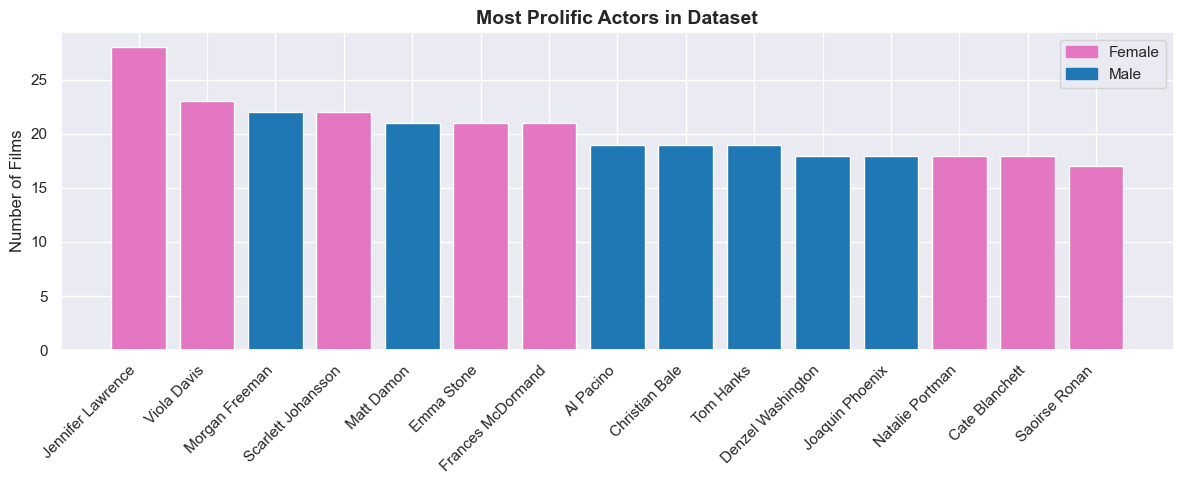

In [16]:
colors = ['#e377c2' if g=='F' else '#1f77b4' for g in actor_stats['gender']]
fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(actor_stats['actor'], actor_stats['num_films'], color=colors)
ax.set_xticklabels(actor_stats['actor'], rotation=45, ha='right')
ax.set_ylabel('Number of Films')
ax.set_title('Most Prolific Actors in Dataset')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#e377c2',label='Female'),
                   Patch(color='#1f77b4',label='Male')])
plt.tight_layout()
plt.show()

### 6.2 Budget vs. Gross — ROI analysis with regression

In [17]:
roi_df = sql('''
SELECT title, genre,
       budget_usd/1e6  AS budget_m,
       gross_usd/1e6   AS gross_m,
       ROUND((gross_usd - budget_usd)*100.0/NULLIF(budget_usd,0), 1) AS roi_pct,
       imdb_rating
FROM movies
WHERE budget_usd > 0
ORDER BY roi_pct DESC
''', n=5)

,title,genre,budget_m,gross_m,roi_pct,imdb_rating
0,Blood Simple,Drama,201.783161,1021.870889,406.4,7.0
1,Y Tu Mama También,Horror,235.191961,1118.547221,375.6,7.3
2,My Neighbor Totoro,Comedy,62.770953,277.984099,342.9,7.7
3,Blue Velvet,Sci-Fi,45.194440,184.219387,307.6,7.9
4,Pulp Fiction,Biography,149.187279,600.140712,302.3,6.7


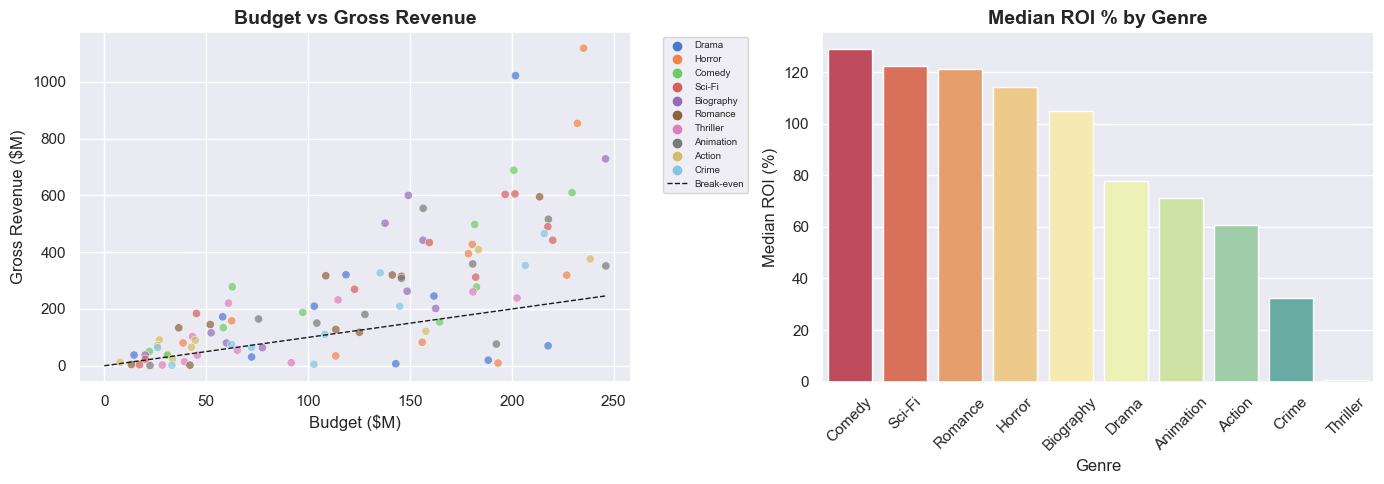

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Scatter: budget vs gross
sns.scatterplot(data=roi_df, x='budget_m', y='gross_m',
                hue='genre', alpha=0.7, ax=axes[0])
axes[0].plot([0, roi_df['budget_m'].max()],
             [0, roi_df['budget_m'].max()],
             'k--', linewidth=1, label='Break-even')
axes[0].set_title('Budget vs Gross Revenue')
axes[0].set_xlabel('Budget ($M)')
axes[0].set_ylabel('Gross Revenue ($M)')
axes[0].legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize=7)

# ROI distribution by genre
genre_roi = roi_df.groupby('genre')['roi_pct'].median().sort_values(ascending=False)
sns.barplot(x=genre_roi.index, y=genre_roi.values, ax=axes[1], palette='Spectral')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Median ROI % by Genre')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Median ROI (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 6.3 Window Functions — rank movies within each genre

In [19]:
ranked = sql('''
SELECT title, genre, imdb_rating,
       RANK()  OVER (PARTITION BY genre ORDER BY imdb_rating DESC) AS genre_rank,
       ROUND(AVG(imdb_rating) OVER (PARTITION BY genre), 2)        AS genre_avg,
       ROUND(imdb_rating - AVG(imdb_rating) OVER (PARTITION BY genre), 2) AS vs_genre_avg
FROM movies
ORDER BY genre, genre_rank
''', n=15)

,title,genre,imdb_rating,genre_rank,genre_avg,vs_genre_avg
0,Goodfellas,Action,8.5,1,7.31,1.19
1,Arrival,Action,7.9,2,7.31,0.59
2,Spirited Away,Action,7.9,2,7.31,0.59
3,The Silence of the Lambs,Action,7.8,4,7.31,0.49
4,Inception,Action,7.6,5,7.31,0.29
5,All About My Mother,Action,7.4,6,7.31,0.09
6,The Godfather,Action,7.0,7,7.31,-0.31
7,Fight Club,Action,6.8,8,7.31,-0.51
8,Heat,Action,6.3,9,7.31,-1.01
9,The Grand Budapest Hotel,Action,5.9,10,7.31,-1.41


### 6.4 Running total gross revenue by year (cumulative)

In [20]:
cumulative = sql('''
SELECT release_year,
       ROUND(SUM(gross_usd)/1e6, 1)                                         AS yearly_gross_m,
       ROUND(SUM(SUM(gross_usd)) OVER (ORDER BY release_year)/1e6, 1)       AS cumulative_gross_m
FROM movies
GROUP BY release_year
ORDER BY release_year
''')

,release_year,yearly_gross_m,cumulative_gross_m
0,1970,84.5,84.5
1,1972,453.5,538.0
2,1973,121.7,659.7
3,1974,1179.9,1839.7
4,1975,853.8,2693.4
5,1976,116.2,2809.6
6,1977,238.6,3048.2
7,1978,951.6,3999.8
8,1979,595.2,4595.0
9,1980,608.8,5203.8


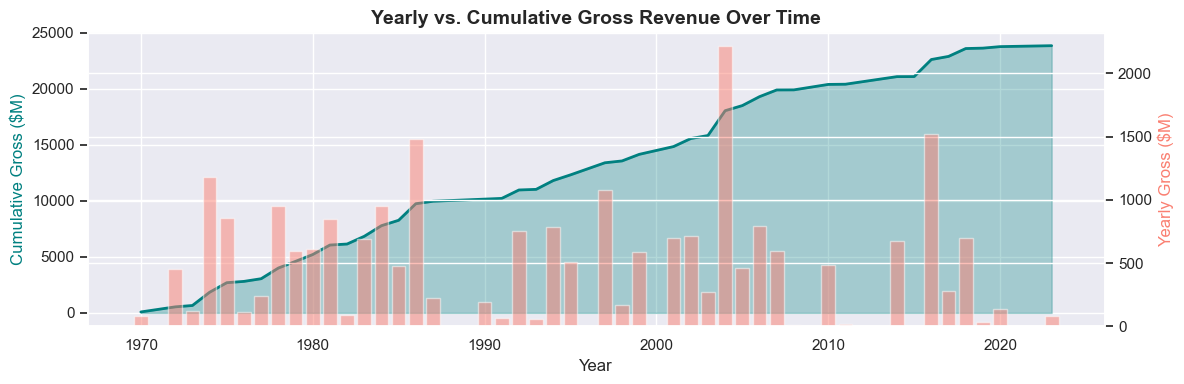

In [21]:
fig, ax = plt.subplots(figsize=(12,4))
ax.fill_between(cumulative['release_year'], cumulative['cumulative_gross_m'],
                alpha=0.3, color='teal')
ax.plot(cumulative['release_year'], cumulative['cumulative_gross_m'],
        color='teal', linewidth=2)
ax2 = ax.twinx()
ax2.bar(cumulative['release_year'], cumulative['yearly_gross_m'],
        alpha=0.5, color='salmon', width=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Cumulative Gross ($M)', color='teal')
ax2.set_ylabel('Yearly Gross ($M)', color='salmon')
ax.set_title('Yearly vs. Cumulative Gross Revenue Over Time')
plt.tight_layout()
plt.show()

### 6.5 CTE — High-value movies (above-average rating AND above-average gross)

In [22]:
high_value = sql('''
WITH averages AS (
    SELECT AVG(imdb_rating)  AS avg_rating,
           AVG(gross_usd)    AS avg_gross
    FROM movies
),
high_value_movies AS (
    SELECT m.title, m.genre, m.imdb_rating,
           ROUND(m.gross_usd/1e6,1) AS gross_m,
           d.name AS director
    FROM movies m
    JOIN directors d ON m.director_id = d.director_id
    CROSS JOIN averages a
    WHERE m.imdb_rating > a.avg_rating
      AND m.gross_usd    > a.avg_gross
)
SELECT * FROM high_value_movies
ORDER BY imdb_rating DESC
LIMIT 15
''')

,title,genre,imdb_rating,gross_m,director
0,Rushmore,Sci-Fi,8.9,442.2,Stanley Kubrick
1,North by Northwest,Animation,8.9,516.1,Denis Villeneuve
2,Dunkirk,Sci-Fi,8.6,434.0,Denis Villeneuve
3,The Godfather Part II,Thriller,8.5,238.6,Hayao Miyazaki
4,A Little Princess,Drama,8.2,320.5,Christopher Nolan
5,The Martian,Romance,8.1,317.1,Bong Joon-ho
6,Rumble Fish,Sci-Fi,8.0,269.5,Pedro Almodóvar
7,Zodiac,Comedy,7.9,688.9,Quentin Tarantino
8,My Neighbor Totoro,Comedy,7.7,278.0,Quentin Tarantino
9,The Skin I Live In,Crime,7.7,465.6,Christopher Nolan


### 6.6 Genre heatmap — avg rating per decade

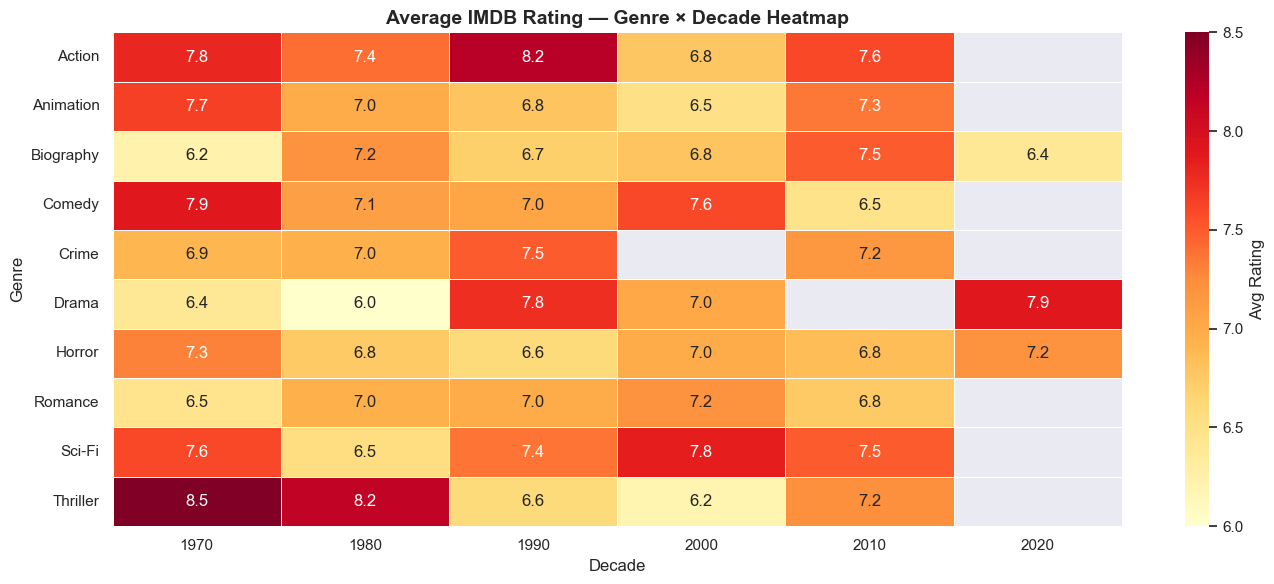

In [23]:
heatmap_df = pd.read_sql_query('''
SELECT (release_year/10)*10 AS decade, genre,
       ROUND(AVG(imdb_rating),2) AS avg_rating
FROM movies
GROUP BY decade, genre
''', conn)

pivot = heatmap_df.pivot(index='genre', columns='decade', values='avg_rating')

fig, ax = plt.subplots(figsize=(14,6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Avg Rating'})
ax.set_title('Average IMDB Rating — Genre × Decade Heatmap')
ax.set_xlabel('Decade')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.show()

### 6.7 Runtime vs Rating correlation

,runtime_min,imdb_rating,genre,votes
0,169,7.6,Action,471956
1,92,7.8,Thriller,1032150
2,169,7.0,Comedy,434895
3,129,8.6,Sci-Fi,369647
4,102,6.8,Crime,129978
5,78,6.8,Biography,2124613
6,158,7.4,Horror,838985
7,103,5.6,Romance,2290650
8,178,6.3,Animation,2476559
9,129,6.4,Drama,674659


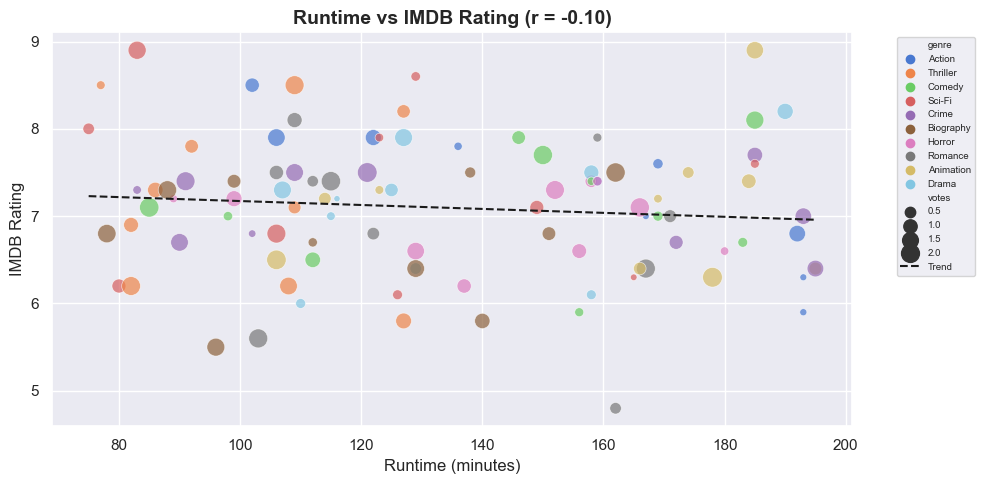

In [24]:
runtime_df = sql('''
SELECT runtime_min, imdb_rating, genre, votes
FROM movies
WHERE runtime_min BETWEEN 60 AND 220
''')

fig, ax = plt.subplots(figsize=(10,5))
sns.scatterplot(data=runtime_df, x='runtime_min', y='imdb_rating',
                hue='genre', size='votes', sizes=(20,200),
                alpha=0.7, ax=ax)
# Regression line
z = np.polyfit(runtime_df['runtime_min'], runtime_df['imdb_rating'], 1)
p = np.poly1d(z)
xline = np.linspace(runtime_df['runtime_min'].min(), runtime_df['runtime_min'].max(), 100)
ax.plot(xline, p(xline), 'k--', linewidth=1.5, label='Trend')
corr = runtime_df['runtime_min'].corr(runtime_df['imdb_rating'])
ax.set_title(f'Runtime vs IMDB Rating (r = {corr:.2f})')
ax.set_xlabel('Runtime (minutes)')
ax.set_ylabel('IMDB Rating')
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

### 6.8 Top countries by total movies & avg rating

In [25]:
country_df = sql('''
SELECT country,
       COUNT(*)                     AS num_movies,
       ROUND(AVG(imdb_rating),2)    AS avg_rating,
       ROUND(SUM(gross_usd)/1e6,1)  AS total_gross_m
FROM movies
GROUP BY country
ORDER BY num_movies DESC
''')

,country,num_movies,avg_rating,total_gross_m
0,USA,10,7.09,2136.4
1,UK,10,7.31,1301.0
2,Spain,10,6.96,3479.7
3,South Korea,10,7.10,1677.4
4,Japan,10,7.35,3367.2
5,Italy,10,6.77,3035.7
6,Germany,10,6.89,2078.4
7,France,10,7.13,2915.7
8,Canada,10,7.25,1174.3
9,Australia,10,7.11,2662.6


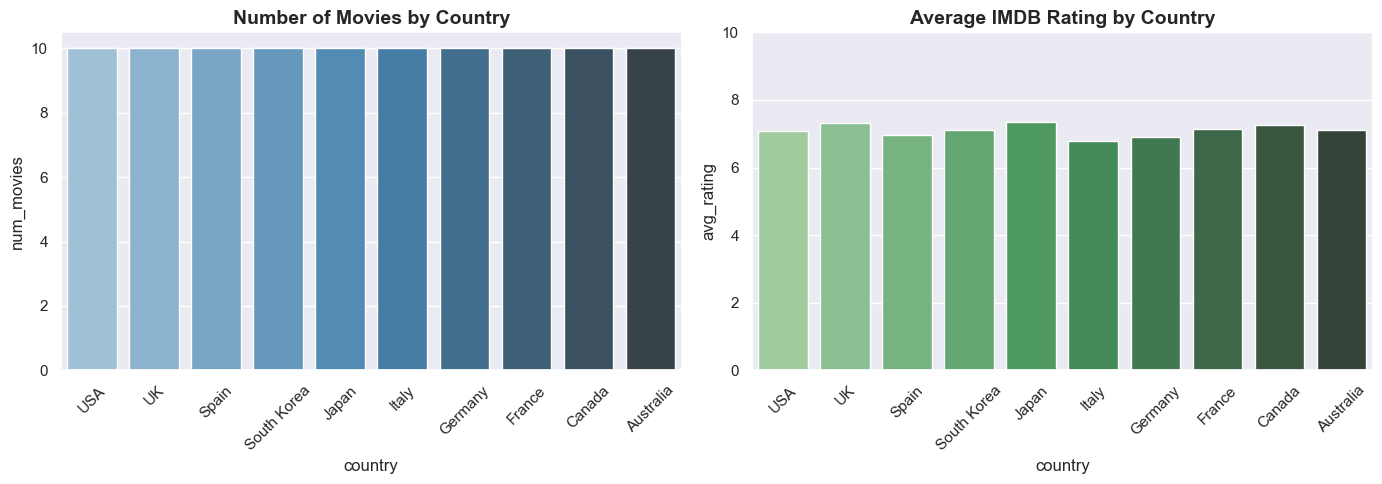

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.barplot(data=country_df, x='country', y='num_movies',
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Number of Movies by Country')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=country_df, x='country', y='avg_rating',
            palette='Greens_d', ax=axes[1])
axes[1].set_title('Average IMDB Rating by Country')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

---
## 7. Summary Statistics

In [27]:
summary = sql('''
SELECT
    COUNT(*)                          AS total_movies,
    ROUND(AVG(imdb_rating),2)         AS mean_rating,
    MIN(imdb_rating)                  AS min_rating,
    MAX(imdb_rating)                  AS max_rating,
    ROUND(AVG(budget_usd/1e6),1)      AS mean_budget_m,
    ROUND(AVG(gross_usd/1e6),1)       AS mean_gross_m,
    ROUND(AVG(runtime_min),1)         AS mean_runtime_min,
    MIN(release_year)                 AS earliest_year,
    MAX(release_year)                 AS latest_year
FROM movies
''')
print('\n✅ Analysis complete!')

,total_movies,mean_rating,min_rating,max_rating,mean_budget_m,mean_gross_m,mean_runtime_min,earliest_year,latest_year
0,100,7.1,4.8,8.9,119.6,238.3,134.2,1970,2023



✅ Analysis complete!


---
## 8. Close Connection

In [28]:
conn.close()
print('🎬 IMDB SQL Analysis complete. Database connection closed.')

🎬 IMDB SQL Analysis complete. Database connection closed.
